In [18]:
import pandas as pd
df=pd.read_excel('iris_no_species.xlsx')
df

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


演習問題1

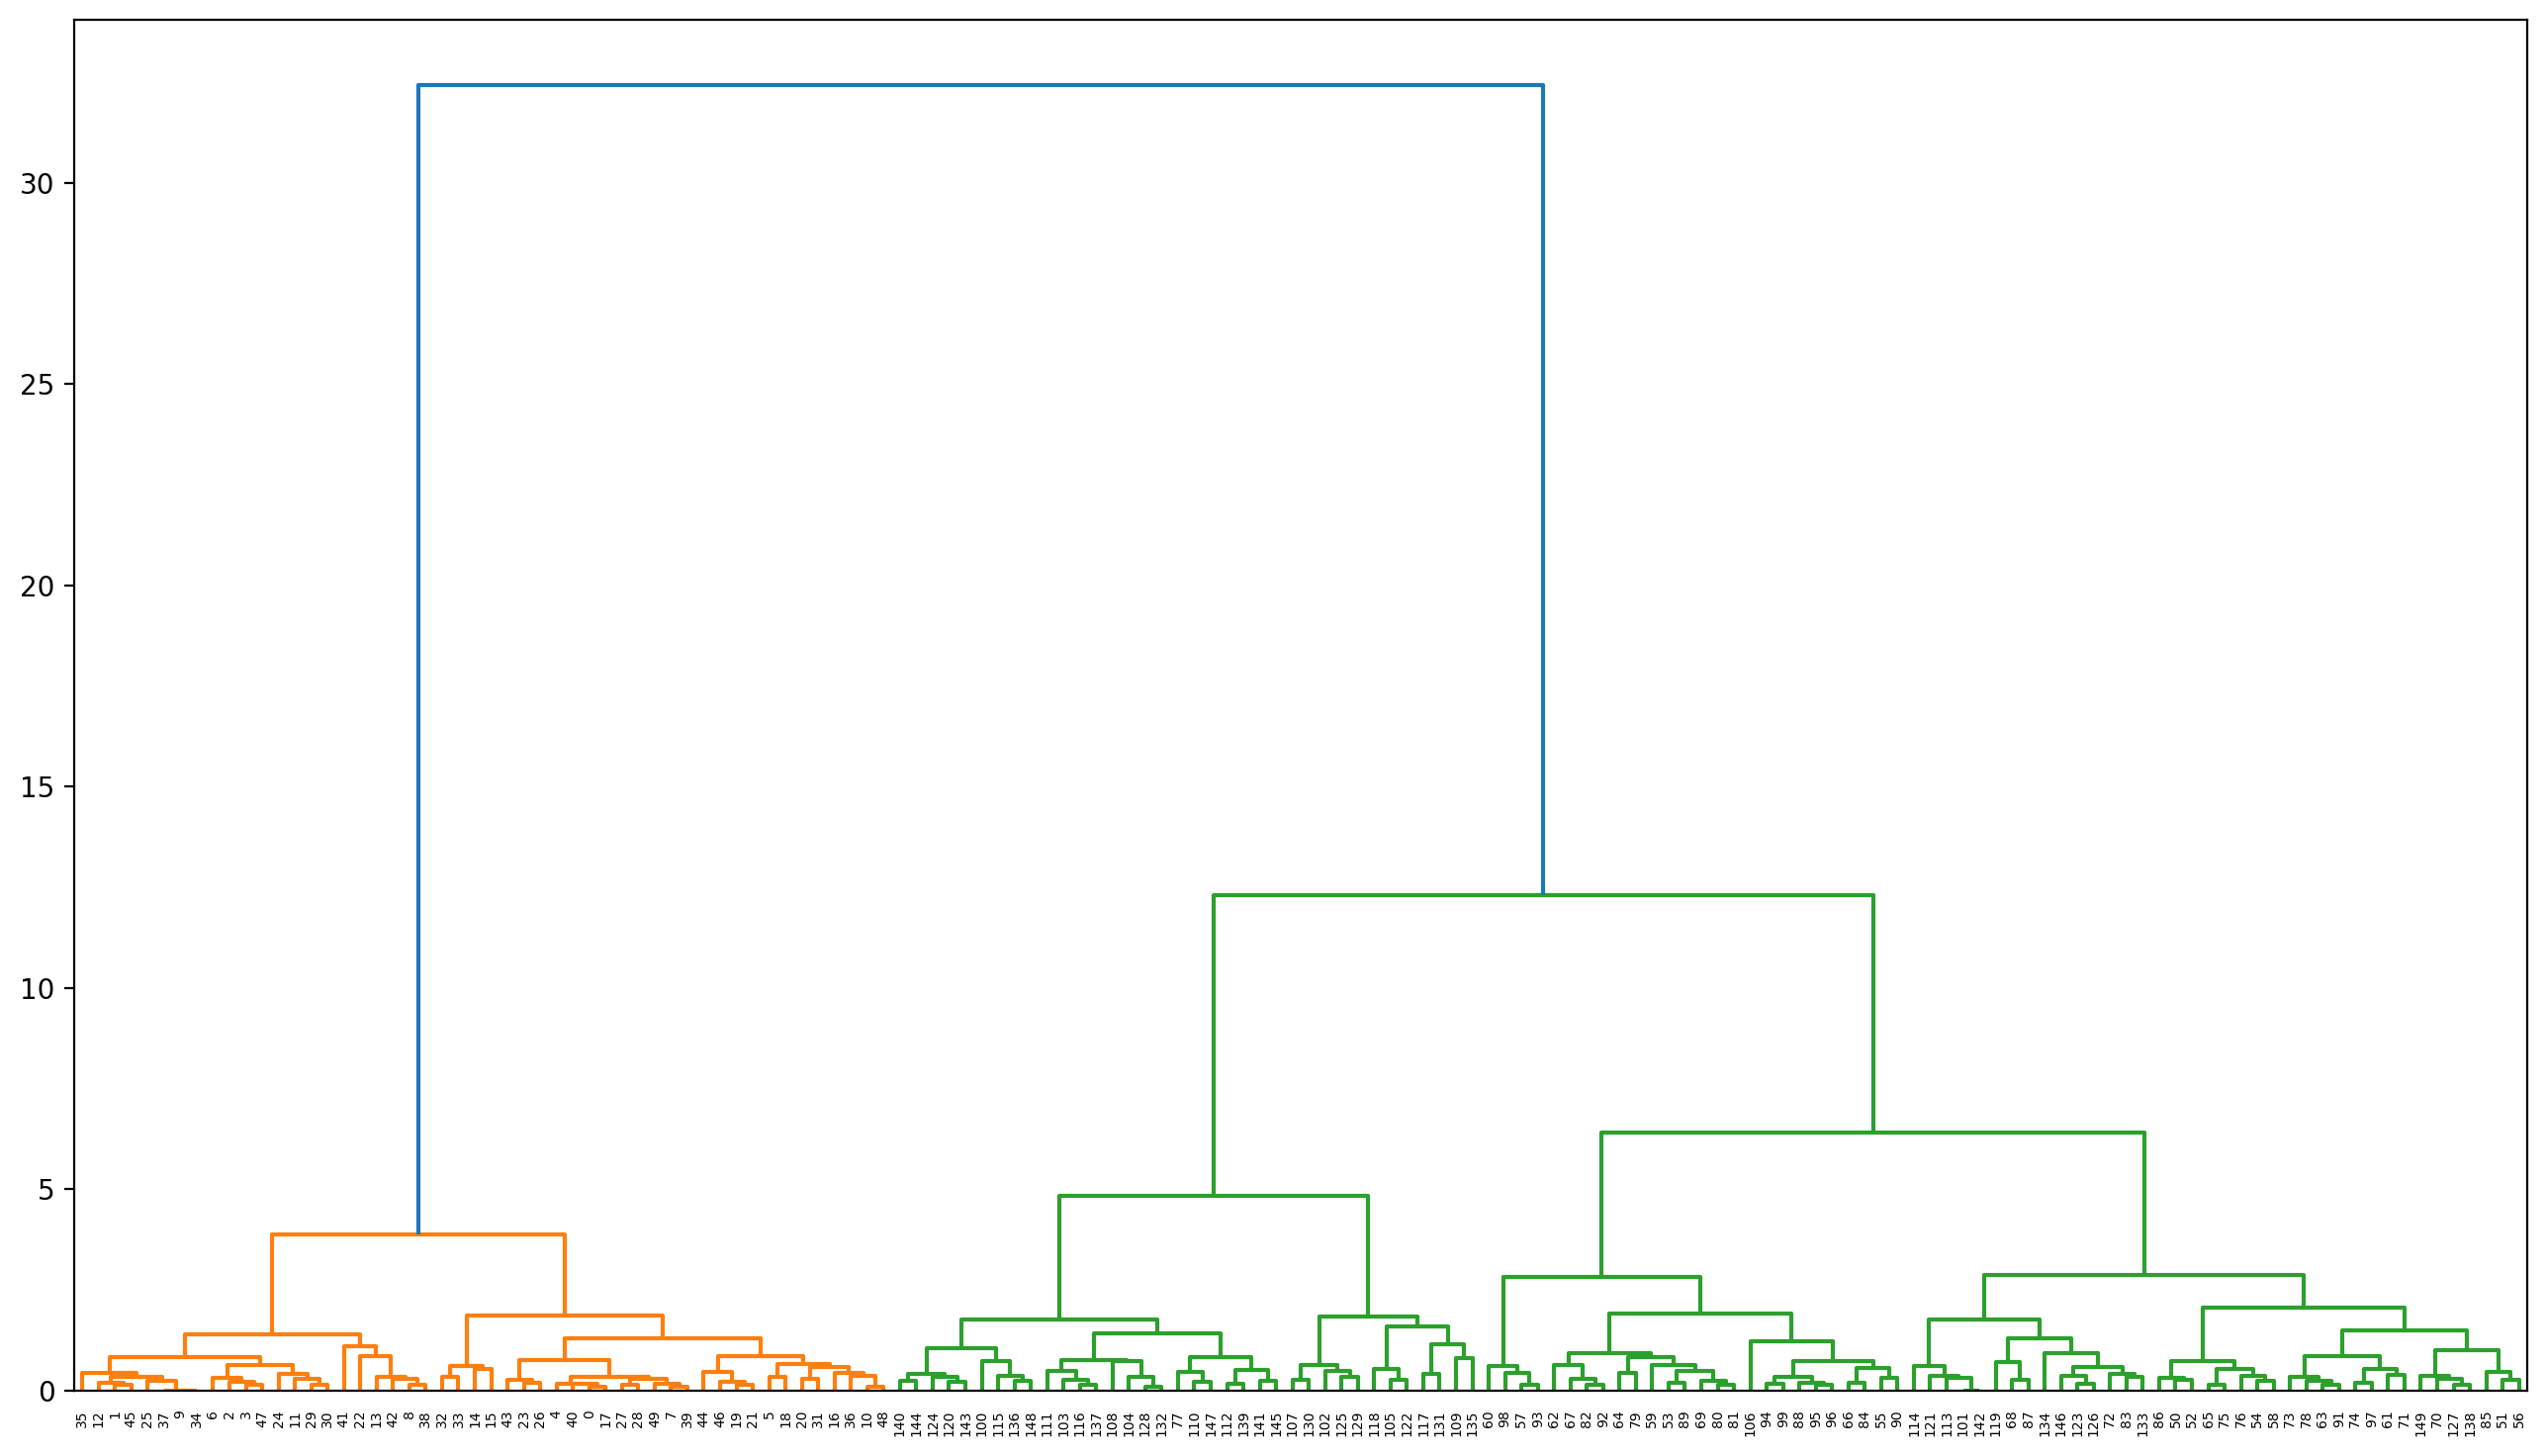

In [19]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

linkage_result = linkage(df, method='ward', metric='euclidean')
plt.figure(num=None, figsize=(16, 9), dpi=200, facecolor='w', edgecolor='k')
dendrogram(linkage_result, labels=df.index)
plt.show()

クラスタの形成過程を視覚的に把握できるが、データ数が多く、複雑でわかりにくい

演習問題2

In [20]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=4, random_state=0)
result = km.fit_predict(df)
result

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 0, 3, 0, 3, 0, 3, 0, 0, 0, 0, 3, 0, 3,
       0, 0, 3, 0, 3, 0, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 3, 0, 3, 3, 3,
       0, 0, 0, 3, 0, 0, 0, 0, 0, 3, 0, 0, 2, 3, 2, 2, 2, 2, 0, 2, 2, 2,
       3, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 3, 2, 3], dtype=int32)

In [21]:
print('Distortion:%.2f'% km.inertia_)

Distortion:57.32


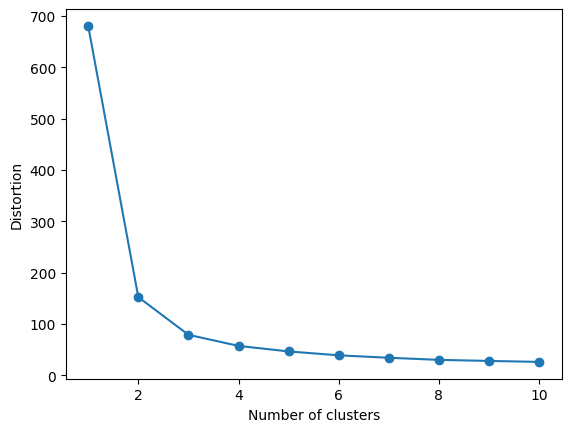

In [22]:
distortions = []
for i in range(1,11):
  km = KMeans(n_clusters=i, init='k-means++',n_init=10, max_iter=300, random_state=0)
  km.fit(df)
  distortions.append(km.inertia_)

plt.plot(range(1,11),distortions,marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

クラスタ数3でも良さそう

In [23]:
km = KMeans(n_clusters=3, random_state=0)
result = km.fit_predict(df)

In [24]:
print('Distortion:%.2f'% km.inertia_)

Distortion:78.95


In [25]:
df['cluster_id'] = result
df

,sepal.length,sepal.width,petal.length,petal.width,cluster_id
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,0
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [26]:
df['cluster_id'].value_counts()

,count
cluster_id,
0,61
1,50
2,39


In [27]:
grand_total = df.groupby('cluster_id').mean()
grand_total

,sepal.length,sepal.width,petal.length,petal.width
cluster_id,,,,
0,5.883607,2.740984,4.388525,1.434426
1,5.006000,3.418000,1.464000,0.244000
2,6.853846,3.076923,5.715385,2.053846


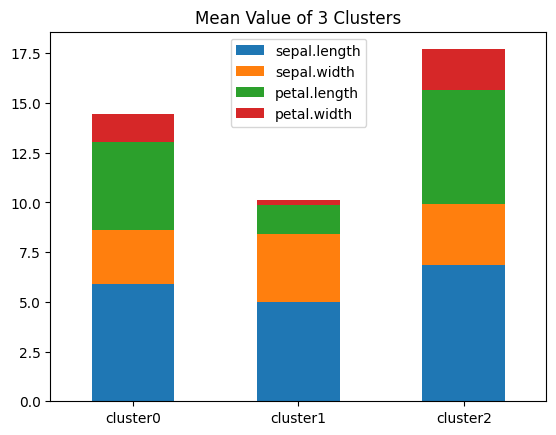

In [28]:
clusterinfo = pd.DataFrame()
for i in range(3):
  clusterinfo['cluster' + str(i)] = df[df['cluster_id'] == i].mean()
clusterinfo = clusterinfo.drop('cluster_id')

stacked_bar = clusterinfo.T.plot(kind='bar', stacked=True, title="Mean Value of 3 Clusters")
stacked_bar.set_xticklabels(stacked_bar.xaxis.get_majorticklabels(),rotation=0)
plt.show()

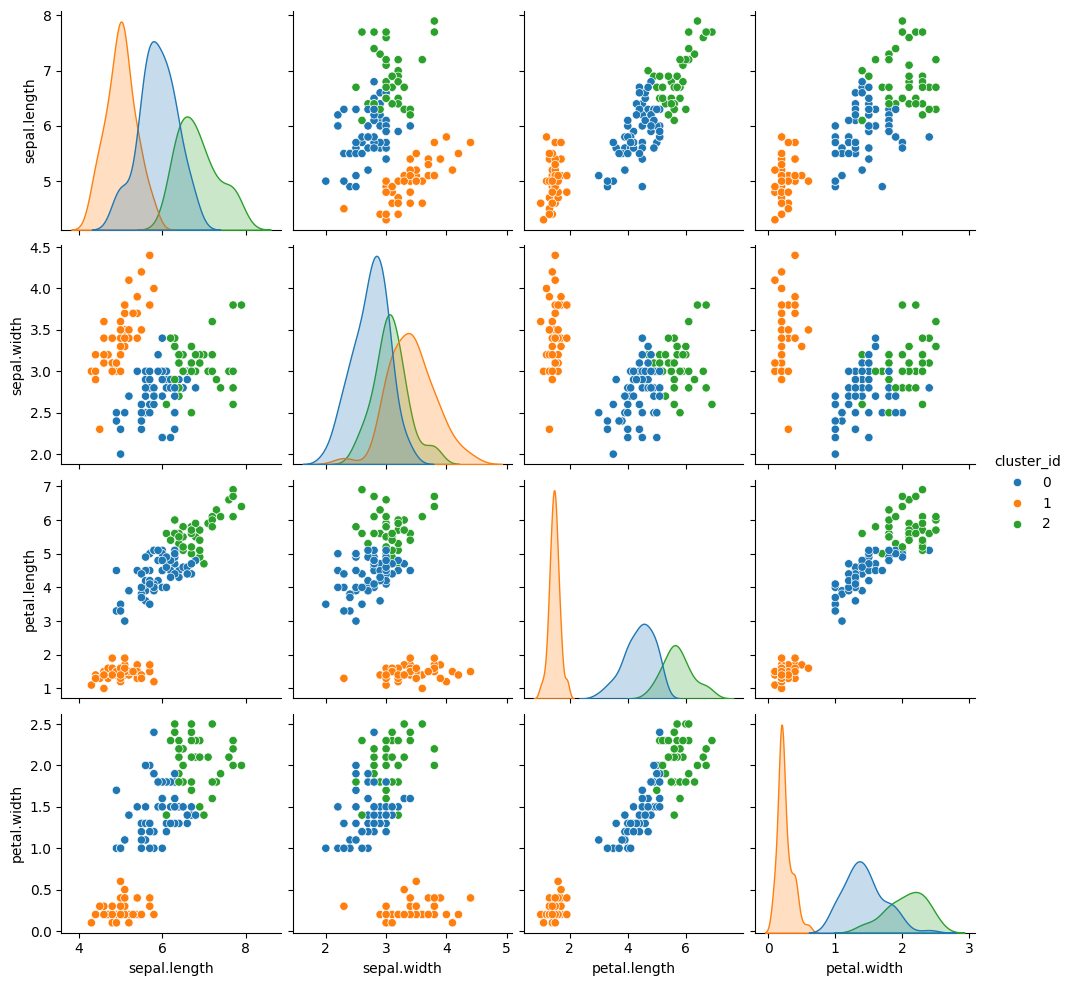

In [29]:
import seaborn as sns

sns.pairplot(df, hue='cluster_id', diag_kind='kde', palette='tab10')
plt.show()

petal.lengthとpetal.widthとの間に正の相関がみられる

つまり、今回のクラスタリングには花弁の長さと幅のデータをもとに分けていると考えられ、実際他のデータ同士の関係は分散していることが確認できる。